<a href="https://colab.research.google.com/github/Harshitha-hunny/part-3/blob/main/churn_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [683]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import confusion_matrix




from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [684]:
rfm= pd.read_csv('/content/drive/MyDrive/T2_Project_harshitha /d2c churn data package/rfm_modeling_snapshot.csv')
rfm.head()

,customer_id,snapshot_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,marketing_consent,recency_days,frequency_180d,...,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,churn_next_60d,split
0,CUST00001,2025-09-30,Tier 1,18-24,Instagram,Silver,Makeup,Yes,107,1,...,1,4,0,0,0,2,0,20,1,train
1,CUST00002,2025-09-30,Tier 2,25-34,Marketplace,Silver,Hair Care,Yes,40,1,...,8,31,4,2,3,0,0,0,0,train
2,CUST00003,2025-09-30,Tier 1,25-34,Influencer,NaN,Skin Care,Yes,171,1,...,1,3,0,0,0,0,0,26,1,train
3,CUST00004,2025-09-30,Tier 3,25-34,Google Search,NaN,Fragrance,No,131,1,...,1,6,0,0,0,0,0,14,1,train
4,CUST00005,2025-09-30,Tier 3,35-44,Organic,Gold,Hair Care,Yes,38,3,...,18,95,4,1,1,3,1,9,0,train


In [685]:

print(rfm.isnull().sum())
print(rfm.duplicated().sum())
rfm.info()

customer_id                    0
snapshot_date                  0
city_tier                      0
age_group                      0
acquisition_channel            0
loyalty_tier                1386
preferred_category             0
marketing_consent              0
recency_days                   0
frequency_180d                 0
monetary_180d                  0
return_rate_180d               0
avg_discount_pct_180d          0
avg_rating_180d                0
category_diversity_180d        0
ticket_count_90d               0
negative_ticket_rate_90d       0
avg_resolution_hours_90d       0
days_since_signup              0
sessions_30d                   0
product_views_30d              0
cart_adds_30d                  0
wishlist_adds_30d              0
abandoned_carts_30d            0
email_opens_30d                0
campaign_clicks_30d            0
last_visit_days_ago            0
churn_next_60d                 0
split                          0
dtype: int64
0
<class 'pandas.core.frame.Da

##Clearly separate train, validation, and test data using the provided split

In [686]:
target = 'churn_next_60d'
categorical_cols = ['city_tier', 'age_group', 'acquisition_channel', 'loyalty_tier', 'preferred_category', 'marketing_consent']

features = ['split', target, 'customer_id', 'snapshot_date']

# 1. Clearly separate train, validation, and test data using the provided split
X_train_raw = rfm[rfm['split'] == 'train'].drop(columns=features, errors='ignore')
y_train = rfm[rfm['split'] == 'train'][target]

X_val_raw =rfm[rfm['split'] == 'validation'].drop(columns=features, errors='ignore')
y_val = rfm[rfm['split'] == 'validation'][target]

X_test_raw = rfm[rfm['split'] == 'test'].drop(columns=features, errors='ignore')
y_test = rfm[rfm['split'] == 'test'][target]

# 2. One-hot encode categorical features
X_combined_raw = pd.concat([X_train_raw, X_val_raw, X_test_raw], ignore_index=True)
X_encoded = pd.get_dummies(X_combined_raw, columns=categorical_cols, drop_first=True)



In [687]:
X_combined_raw.head()

,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,marketing_consent,recency_days,frequency_180d,monetary_180d,return_rate_180d,...,avg_resolution_hours_90d,days_since_signup,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago
0,Tier 1,18-24,Instagram,Silver,Makeup,Yes,107,1,362.73,0.0,...,0.0,524,1,4,0,0,0,2,0,20
1,Tier 2,25-34,Marketplace,Silver,Hair Care,Yes,40,1,581.00,0.0,...,1.0,121,8,31,4,2,3,0,0,0
2,Tier 1,25-34,Influencer,NaN,Skin Care,Yes,171,1,649.98,0.0,...,0.0,206,1,3,0,0,0,0,0,26
3,Tier 3,25-34,Google Search,NaN,Fragrance,No,131,1,1604.04,0.0,...,0.0,168,1,6,0,0,0,0,0,14
4,Tier 3,35-44,Organic,Gold,Hair Care,Yes,38,3,1781.90,0.0,...,0.0,405,18,95,4,1,1,3,1,9


In [688]:
X_encoded.head()

,recency_days,frequency_180d,monetary_180d,return_rate_180d,avg_discount_pct_180d,avg_rating_180d,category_diversity_180d,ticket_count_90d,negative_ticket_rate_90d,avg_resolution_hours_90d,...,acquisition_channel_Organic,acquisition_channel_Referral,loyalty_tier_Platinum,loyalty_tier_Silver,preferred_category_Fragrance,preferred_category_Hair Care,preferred_category_Makeup,preferred_category_Skin Care,preferred_category_Wellness,marketing_consent_Yes
0,107,1,362.73,0.0,0.23,3.0,1,0,0.0,0.0,...,False,False,False,True,False,False,True,False,False,True
1,40,1,581.00,0.0,0.23,4.0,1,1,0.0,1.0,...,False,False,False,True,False,True,False,False,False,True
2,171,1,649.98,0.0,0.47,2.0,1,0,0.0,0.0,...,False,False,False,False,False,False,False,True,False,True
3,131,1,1604.04,0.0,0.16,2.0,1,0,0.0,0.0,...,False,False,False,False,True,False,False,False,False,False
4,38,3,1781.90,0.0,0.48,1.0,2,0,0.0,0.0,...,True,False,False,False,False,True,False,False,False,True


In [689]:
# 3. Re-split into train, validation, and test sets
train_idx = len(X_train_raw)
val_idx = train_idx + len(X_val_raw)

X_train = X_encoded.iloc[:train_idx]
X_val = X_encoded.iloc[train_idx:val_idx]
X_test = X_encoded.iloc[val_idx:]

print(f'Data split successfully!')
print(f'Features: {X_train.shape[1]}')
print(f'Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}')

Data split successfully!
Features: 37
Train: 1728, Val: 336, Test: 336


##model training


1)one simple baseline model(logistic regression)


In [690]:
#  baseline model (Logistic Regression)
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000, random_state=42)

2)one stronger model ( Random Forest)

In [691]:
# 5. Re-train the stronger model (Random Forest) on cleaned data
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)


RandomForestClassifier(max_depth=10, random_state=42)

##Evaluate the model using metrics suitable for churn classification

###  Evaluation for Logistic Regression

classification_report              precision    recall  f1-score   support

           0       0.82      0.83      0.82       168
           1       0.83      0.82      0.82       168

    accuracy                           0.82       336
   macro avg       0.82      0.82      0.82       336
weighted avg       0.82      0.82      0.82       336

Accuracy: 0.8214
Precision: 0.8253
Recall: 0.8155
F1-Score: 0.8204
ROC AUC Score: 0.8863

Confusion Matrix (Logistic Regression):
[[139  29]
 [ 31 137]]


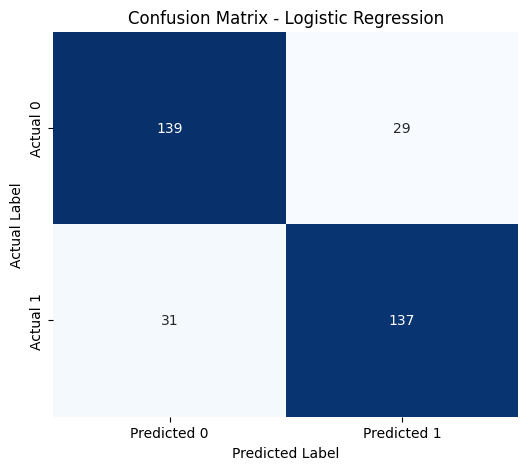

In [692]:
lr_test_pred = lr_model.predict(X_test)
lr_test_prob = lr_model.predict_proba(X_test)[:, 1]


print(f"classification_report{classification_report(y_test, lr_test_pred)}")
print(f"Accuracy: {accuracy_score(y_test, lr_test_pred):.4f}")
print(f"Precision: {precision_score(y_test, lr_test_pred):.4f}")
print(f"Recall: {recall_score(y_test, lr_test_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, lr_test_pred):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, lr_test_prob):.4f}")
cm_lr= confusion_matrix(y_test, lr_test_pred)
print("\nConfusion Matrix (Logistic Regression):")
print(cm_lr)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

### Evaluation for Random Forest

classification report : 
              precision    recall  f1-score   support

           0       0.77      0.83      0.80       168
           1       0.81      0.76      0.78       168

    accuracy                           0.79       336
   macro avg       0.79      0.79      0.79       336
weighted avg       0.79      0.79      0.79       336

Accuracy: 0.7917
Precision: 0.8141
Recall: 0.7560
F1-Score: 0.7840
ROC AUC Score: 0.8760

Confusion Matrix (Random Forest):
[[139  29]
 [ 41 127]]


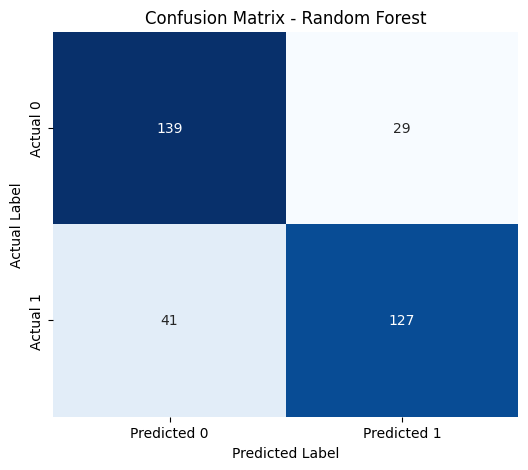

In [693]:
rf_test_pred = rf_model.predict(X_test)
rf_test_prob = rf_model.predict_proba(X_test)[:, 1]


print(f"classification report : \n{classification_report(y_test, rf_test_pred)}")
print(f"Accuracy: {accuracy_score(y_test, rf_test_pred):.4f}")
print(f"Precision: {precision_score(y_test, rf_test_pred):.4f}")
print(f"Recall: {recall_score(y_test, rf_test_pred):.4f}")
print(f"F1-Score: {f1_score(y_test,rf_test_pred):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, rf_test_prob):.4f}")
cm_rf = confusion_matrix(y_test, rf_test_pred)
print("\nConfusion Matrix (Random Forest):")
print(cm_rf)

# Plotting Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [694]:
evaluation_metrics_lr = {"model name1" : "logistic regression",
        "accuracy_lr": (accuracy_score(y_test, lr_test_pred)),
        "precision_lr":(precision_score(y_test, lr_test_pred)),
        "recall_lr": (recall_score(y_test, lr_test_pred)),
        "f1_score_lr":(f1_score(y_test, lr_test_pred)),
        "ROC AUC Score_lr": roc_auc_score(y_test, lr_test_prob),
        "confusion matrix_lr":confusion_matrix(y_test, lr_test_pred) ,
            "model name2": "Random Forest",
        "accuracy_rf": (accuracy_score(y_test, rf_test_pred)),
        "precision_rf":(precision_score(y_test, rf_test_pred)),
        "recall_rf": (recall_score(y_test, rf_test_pred)),
        "f1_score_rf":(f1_score(y_test, rf_test_pred)),
        "ROC AUC Score_rf": roc_auc_score(y_test, rf_test_prob),
        "confusion matrix_rf":confusion_matrix(y_test, rf_test_pred)
}



In [695]:


for key, value in evaluation_metrics_lr.items():
    if isinstance(value, np.ndarray):
        evaluation_metrics_lr[key] = value.tolist()
    elif isinstance(value, np.generic):
        evaluation_metrics_lr[key] = value.item()

output_filepath = "model_metrics.json"

with open(output_filepath, "w") as json_file:
    json.dump(evaluation_metrics_lr, json_file, indent=4)

print(f"Metrics successfully exported to {output_filepath}!")

Metrics successfully exported to model_metrics.json!


## Decision Threshold Selection and Business Justification



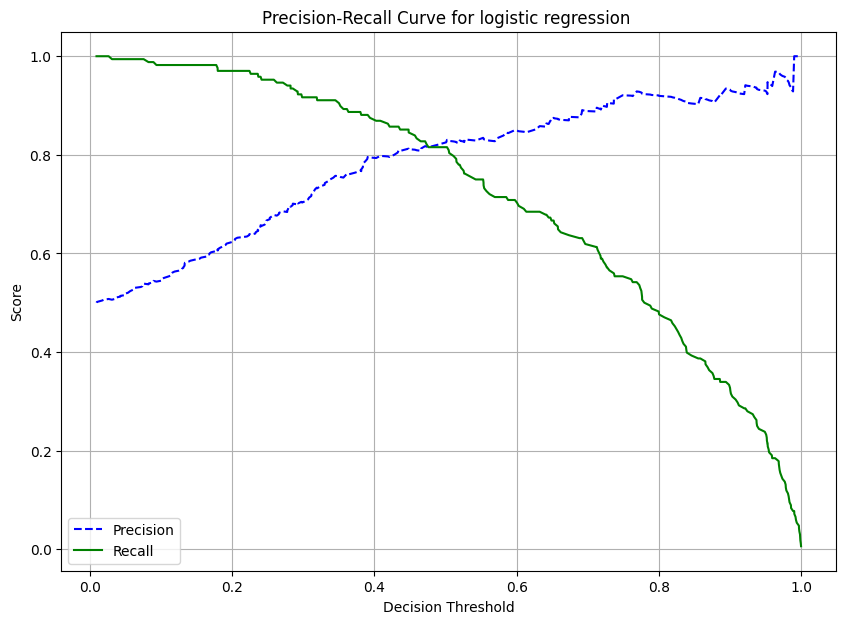

In [696]:
#Calculate precision and recall for various thresholds
precision, recall, thresholds = precision_recall_curve(y_test, lr_test_prob)

# Plotting the Precision-Recall curve
plt.figure(figsize=(10, 7))
plt.plot(thresholds, precision[:-1], 'b--', label='Precision')
plt.plot(thresholds, recall[:-1], 'g-', label='Recall')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall Curve for logistic regression ')
plt.legend()
plt.grid(True)
plt.show()

*   **If minimizing false negatives (maximizing recall) is paramount:**
    *   **Scenario:** The cost of losing a customer is extremely high, and you want to ensure you don't miss any potential churners, even if it means some false positives (sending retention offers to loyal customers). You might choose a **lower threshold** (e.g., 0.3 or 0.4) where recall is high, even if precision is slightly lower.
    *   **Justification:** "We want to maximize the identification of at-risk customers so that our customer success team can intervene. The cost of a missed churner (lost revenue) far outweighs the cost of mistakenly engaging a loyal customer."

*   **If minimizing false positives (maximizing precision) is paramount:**
    *   **Scenario:** Resources for retention campaigns are limited, or you want to avoid irritating loyal customers with unnecessary offers. You need high confidence that a customer predicted to churn actually will. You might choose a **higher threshold** (e.g., 0.6 or 0.7) where precision is high, even if recall is slightly lower.
    *   **Justification:** "Our retention budget is finite, and we want to ensure that our efforts are focused only on customers who are highly likely to churn. We are willing to accept missing some churners to avoid wasting resources or alienating loyal customers."

*   **If a balanced approach is desired:**
    *   **Scenario:** You want a reasonable balance between identifying churners and not over-targeting loyal customers. You might look for the point where precision and recall are relatively close or where the F1-score (which combines precision and recall) is maximized.
    *   **Justification:** "We aim for an effective churn prevention strategy that neither misses too many actual churners nor over-targets non-churners. We'll select a threshold that provides a good equilibrium between identifying at-risk customers and efficient resource allocation."



**threshold of 0.46 provides balance,so the decision treshold is `0.46`**

## Error Analysis: False Positives and False Negatives

In [697]:

# Create a DataFrame for error analysis
error_analysis_df = X_test.copy()
error_analysis_df['actual_churn'] = y_test
error_analysis_df['predicted_churn'] = rf_test_pred

# Filter for false positives (predicted churn, actual no churn)
false_positives = error_analysis_df[(error_analysis_df['actual_churn'] == 0) & (error_analysis_df['predicted_churn'] == 1)]

# Filter for false negatives (predicted no churn, actual churn)
false_negatives = error_analysis_df[(error_analysis_df['actual_churn'] == 1) & (error_analysis_df['predicted_churn'] == 0)]

print(f"Number of False Positives: {len(false_positives)}")
print(f"Number of False Negatives: {len(false_negatives)}")

# Display 10 examples of False Positives
print("\n--- 10 Examples of False Positives ---")
display(false_positives.head(10))

# Display 10 examples of False Negatives
print("\n--- 10 Examples of False Negatives ---")
display(false_negatives.head(10))

Number of False Positives: 10
Number of False Negatives: 13

--- 10 Examples of False Positives ---


,recency_days,frequency_180d,monetary_180d,return_rate_180d,avg_discount_pct_180d,avg_rating_180d,category_diversity_180d,ticket_count_90d,negative_ticket_rate_90d,avg_resolution_hours_90d,...,loyalty_tier_Platinum,loyalty_tier_Silver,preferred_category_Fragrance,preferred_category_Hair Care,preferred_category_Makeup,preferred_category_Skin Care,preferred_category_Wellness,marketing_consent_Yes,actual_churn,predicted_churn
2170,232,0,0.00,0.0,0.000,3.5,0,0,0.0,0.0,...,False,False,False,False,False,True,False,True,0.0,1
2172,148,1,1395.21,0.0,0.180,5.0,1,0,0.0,0.0,...,True,False,False,False,False,True,False,True,0.0,1
2202,159,1,538.57,0.0,0.340,4.0,1,0,0.0,0.0,...,False,False,False,False,False,True,False,True,0.0,1
2228,255,0,0.00,0.0,0.000,3.5,0,0,0.0,0.0,...,False,False,False,False,False,False,False,False,0.0,1
2249,161,2,1246.04,0.0,0.215,4.0,2,0,0.0,0.0,...,False,False,False,False,False,True,False,False,0.0,1
2286,178,1,831.95,0.0,0.140,3.0,1,0,0.0,0.0,...,False,False,True,False,False,False,False,True,0.0,1
2325,153,1,430.99,0.0,0.630,4.0,1,0,0.0,0.0,...,False,True,False,False,False,False,False,True,0.0,1
2337,196,0,0.00,0.0,0.000,3.5,0,0,0.0,0.0,...,False,True,False,False,False,False,False,True,0.0,1
2340,136,1,1097.78,0.0,0.230,3.0,1,0,0.0,0.0,...,False,True,False,False,False,True,False,False,0.0,1
2368,210,0,0.00,0.0,0.000,3.5,0,0,0.0,0.0,...,False,False,False,True,False,False,False,True,0.0,1



--- 10 Examples of False Negatives ---


,recency_days,frequency_180d,monetary_180d,return_rate_180d,avg_discount_pct_180d,avg_rating_180d,category_diversity_180d,ticket_count_90d,negative_ticket_rate_90d,avg_resolution_hours_90d,...,loyalty_tier_Platinum,loyalty_tier_Silver,preferred_category_Fragrance,preferred_category_Hair Care,preferred_category_Makeup,preferred_category_Skin Care,preferred_category_Wellness,marketing_consent_Yes,actual_churn,predicted_churn
2068,5,5,2819.98,0.0,0.362,4.20,4,2,1.0,27.65,...,False,False,False,False,False,False,True,False,1.0,0
2071,72,1,899.51,0.0,0.290,4.00,1,0,0.0,0.00,...,False,False,False,False,False,False,False,True,1.0,0
2102,35,1,837.19,0.0,0.300,5.00,1,0,0.0,0.00,...,False,True,False,False,False,False,False,False,1.0,0
2112,47,2,1908.68,0.0,0.270,5.00,2,0,0.0,0.00,...,False,True,False,True,False,False,False,True,1.0,0
2137,3,2,1674.78,0.0,0.280,4.50,2,0,0.0,0.00,...,False,False,False,True,False,False,False,False,1.0,0
2157,6,3,1449.24,0.0,0.290,4.67,3,1,1.0,28.10,...,False,False,False,False,False,True,False,True,1.0,0
2195,25,2,769.86,0.0,0.475,3.50,2,0,0.0,0.00,...,False,False,True,False,False,False,False,True,1.0,0
2197,40,1,2196.79,0.0,0.300,5.00,1,1,0.0,49.60,...,False,False,False,False,False,True,False,True,1.0,0
2221,54,1,1183.74,1.0,0.360,3.00,1,1,1.0,38.90,...,False,False,False,False,False,False,True,True,1.0,0
2290,0,2,1098.94,0.0,0.280,3.00,2,0,0.0,0.00,...,False,False,False,False,True,False,False,True,1.0,0


## Top Features Driving Predictions

In [698]:

lr_coefficients = lr_model.coef_[0]
lr_features_df = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': lr_coefficients})
lr_features_df['Abs_Coefficient'] = abs(lr_features_df['Coefficient'])
lr_features_df = lr_features_df.sort_values(by='Abs_Coefficient', ascending=False)

print("\n--- Top 10 Features (Logistic Regression - Absolute Coefficients) ---")
display(lr_features_df.head(10))


--- Top 10 Features (Logistic Regression - Absolute Coefficients) ---


,Feature,Coefficient,Abs_Coefficient
3,return_rate_180d,1.100033,1.100033
8,negative_ticket_rate_90d,0.705087,0.705087
27,acquisition_channel_Organic,-0.594236,0.594236
31,preferred_category_Fragrance,-0.527215,0.527215
4,avg_discount_pct_180d,0.433445,0.433445
36,marketing_consent_Yes,-0.320798,0.320798
29,loyalty_tier_Platinum,-0.317775,0.317775
32,preferred_category_Hair Care,-0.293524,0.293524
7,ticket_count_90d,-0.251091,0.251091
1,frequency_180d,-0.203254,0.203254


### Interpretation of Top Features for Logistic Regression

For Logistic Regression, the 'Coefficient' indicates the strength and direction of the relationship between a feature and the log-odds of churn. The absolute value of the coefficient helps in ranking features by the magnitude of their impact.

*   **Positive Coefficient:** A positive coefficient means that as the feature value increases, the likelihood (log-odds) of a customer churning *increases*. For example, a higher `recency_days` (more days since last purchase) would typically correspond to a higher churn probability.

*   **Negative Coefficient:** Conversely, a negative coefficient means that as the feature value increases, the likelihood (log-odds) of a customer churning *decreases*. For instance, a higher `monetary_180d` (more money spent in the last 180 days) would usually indicate a lower churn probability.

Commonly, features related to customer engagement (sessions_30d, product_views_30d, last_visit_days_ago), recent purchase behavior (recency_days, frequency_180d, monetary_180d), and customer service interactions (ticket_count_90d, negative_ticket_rate_90d) are strong indicators of churn.

###final model saving.

In [699]:
import joblib
joblib.dump(lr_model, 'model.pkl')
loaded_pipeline = joblib.load('model.pkl')
predictions = loaded_pipeline.predict(X_test)
print("Predictions made successfully using X_test as example new data.")
print(predictions[:5])

Predictions made successfully using X_test as example new data.
[1 1 0 1 0]
